# CIFAR-10 Advanced CNNs and Pretrained Models

This notebook extends CIFAR-10 modeling with VGG-style convolution blocks, callbacks,
on-the-fly augmentation, parallel convolutional branches, an ImageNet-pretrained ResNet50,
and test-time augmentation.

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *

import numpy as np
import os

import matplotlib.pyplot as plt

from keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from keras.regularizers import l2

from sklearn.metrics import accuracy_score

from keras.callbacks import Callback
from keras.callbacks import LearningRateScheduler
from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
def load_dataset(dataset_name):
  if dataset_name in ['MNIST','Fashion-MNIST']:
    if dataset_name =='MNIST':
      (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    else:
      (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    # add empty color dimension and scale to [0,1]
    x_train = np.float32(np.expand_dims(x_train, -1)/255)
    x_test = np.float32(np.expand_dims(x_test, -1)/255)
  elif dataset_name == 'CIFAR-10':
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train = x_train.astype('float32') / 255
    x_test = x_test.astype('float32') / 255
  else:
    print('Unknown dataset')
    return
  y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
  y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
  return x_train, y_train, x_test, y_test

In [3]:
def plot_results(all_history):
  loss, val_loss, accuracy, val_accuracy = [], [], [], []
  for history in all_history:
    loss += history.history['loss']
    val_loss += history.history['val_loss']
    accuracy += history.history['accuracy']
    val_accuracy += history.history['val_accuracy']

  fig, ax = plt.subplots()
  ax.plot(accuracy,label = 'train')
  ax.plot(val_accuracy,label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(loss,label = 'train')
  ax.plot(val_loss,label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')

In [4]:
# Read data
dataset_name = 'CIFAR-10'
x_train, y_train, x_test, y_test = load_dataset(dataset_name)

val_start = int(x_train.shape[0]*0.85)
# Split training set into training and validation sets
x_train, y_train, x_val, y_val = x_train[:val_start], y_train[:val_start],x_train[val_start:], y_train[val_start:]

# Add mirrored images to training set
x_train = np.append(x_train,x_train[:,:,::-1],axis=0)
y_train = np.append(y_train,y_train,axis=0)

# Add mirrored images to validation set
x_val = np.append(x_val,x_val[:,:,::-1],axis=0)
y_val = np.append(y_val,y_val,axis=0)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2056s 12us/step


In [11]:
def vgg_dropout_bn(input_shape=(32,32,3),blocks=3,branching_factor=2,first_layer_filters=32,dropout=0.2,dense_layer=128):
  model = tf.keras.models.Sequential()
  f = first_layer_filters
  for i in range(blocks):
    if i==0:
      model.add(Conv2D(f, kernel_size=(3, 3), input_shape=input_shape, padding='same', activation="relu"))
    else:
      model.add(Conv2D(f, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(Conv2D(f, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    f = int(f*branching_factor)
  model.add(Flatten())
  if dense_layer>0:
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
  model.add(Dense(10))
  model.add(Activation('softmax'))
  return model

In [12]:
from keras.callbacks import LearningRateScheduler

learning_rates = [.0001]*3 + list(np.linspace(.0001,.001,10)) + list(np.linspace(.001,.0001,20)) + [.0001]*1000

def lr_schedule(epoch):
  initial = -3
  period = 10
  lr = 10**(initial - epoch//period)
  #lr = learning_rates[epoch]
  #print('Learning rate: ', lr)
  return lr

lrs = LearningRateScheduler(lr_schedule, verbose=1)

In [13]:
from keras.callbacks import Callback

class TerminateOnBaseline(Callback):
    """Callback that terminates training when either acc or val_acc reaches a specified baseline
    """
    def __init__(self, monitor='accuracy', baseline=0.9):
        super(TerminateOnBaseline, self).__init__()
        self.monitor = monitor
        self.baseline = baseline

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get(self.monitor)
        if acc is not None:
            if acc >= self.baseline:
                print('Epoch %d: Reached baseline, terminating training' % (epoch))
                self.model.stop_training = True

In [14]:
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
tob = TerminateOnBaseline(monitor='accuracy', baseline=0.99)
lrs = LearningRateScheduler(lr_schedule, verbose=1)
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=4, verbose=1, min_lr=0.0001)

In [15]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=3, verbose=1,min_lr=0.0001)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
tob = TerminateOnBaseline(monitor='accuracy', baseline=0.99)

Dataset: CIFAR-10
Epoch 1/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3853 - loss: 1.7660
Epoch 1: val_accuracy improved from None to 0.54180, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4900 - loss: 1.4174 - val_accuracy: 0.5418 - val_loss: 1.2943 - learning_rate: 0.0100
Epoch 2/100
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6519 - loss: 0.9765
Epoch 2: val_accuracy improved from 0.54180 to 0.56573, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6819 - loss: 0.8984 - val_accuracy: 0.5657 - val_loss: 1.4429 - learning_rate: 0.0100
Epoch 3/100
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7112 - loss: 0.8214
Epoch 3: val_accuracy did not improve from 0.56573
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7363 - loss: 0.7518 - val_accuracy: 0.3935 - val_loss: 2.3629 - learning_rate: 0.0100
Epoch 4/100
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7410 - loss: 0.7436
Epoch 4: val_accuracy improved from 0.56573 to 0.68060, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7648 - loss: 0.6747 - val_accuracy: 0.6806 - val_loss: 1.0214 - learning_rate: 0.0100
Epoch 5/100
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7913 - loss: 0.5946
Epoch 5: val_accuracy improved from 0.68060 to 0.75480, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7957 - loss: 0.5811 - val_accuracy: 0.7548 - val_loss: 0.7528 - learning_rate: 0.0100
Epoch 6/100
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7660 - loss: 0.6718
Epoch 6: val_accuracy improved from 0.75480 to 0.76360, saving model to best_model.h5


...


Epoch 30: finished saving model to best_model.h5

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9576 - loss: 0.1176 - val_accuracy: 0.8786 - val_loss: 0.4676 - learning_rate: 0.0012
Epoch 31/100
331/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9600 - loss: 0.1118
Epoch 31: val_accuracy improved from 0.87860 to 0.88013, saving model to best_model.h5



Epoch 31: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9598 - loss: 0.1115 - val_accuracy: 0.8801 - val_loss: 0.4651 - learning_rate: 6.2500e-04
Epoch 32/100
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9613 - loss: 0.1079
Epoch 32: val_accuracy improved from 0.88013 to 0.88047, saving model to best_model.h5



Epoch 32: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9615 - loss: 0.1083 - val_accuracy: 0.8805 - val_loss: 0.4671 - learning_rate: 6.2500e-04
Epoch 33/100
326/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9621 - loss: 0.1046
Epoch 33: val_accuracy improved from 0.88047 to 0.88147, saving model to best_model.h5



Epoch 33: finished saving model to best_model.h5

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9617 - loss: 0.1056 - val_accuracy: 0.8815 - val_loss: 0.4692 - learning_rate: 6.2500e-04
Epoch 34/100
331/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9619 - loss: 0.1021
Epoch 34: val_accuracy improved from 0.88147 to 0.88220, saving model to best_model.h5



Epoch 34: finished saving model to best_model.h5
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9622 - loss: 0.1036 - val_accuracy: 0.8822 - val_loss: 0.4720 - learning_rate: 3.1250e-04
Epoch 35/100
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9632 - loss: 0.1004
Epoch 35: val_accuracy did not improve from 0.88220
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9630 - loss: 0.1017 - val_accuracy: 0.8805 - val_loss: 0.4729 - learning_rate: 3.1250e-04
Epoch 36/100
330/333 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9629 - loss: 0.1036
Epoch 36: val_accuracy did not improve from 0.88220

Epoch 36: ReduceLROnPlateau reducing learning rate to 0.00015624999650754035.
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9640 - loss: 0.1016 - val_accuracy: 0.8818 - val_loss: 0.4722 - learning_rate: 3.1250e-04
Epoch 37/100
331/333 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9646 - loss: 0.0976
Epoch 37: val_accuracy did not improve from 0.88220
333/333 ━━━━━━━━

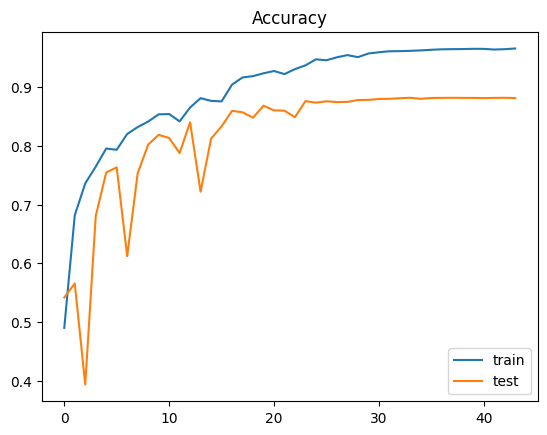

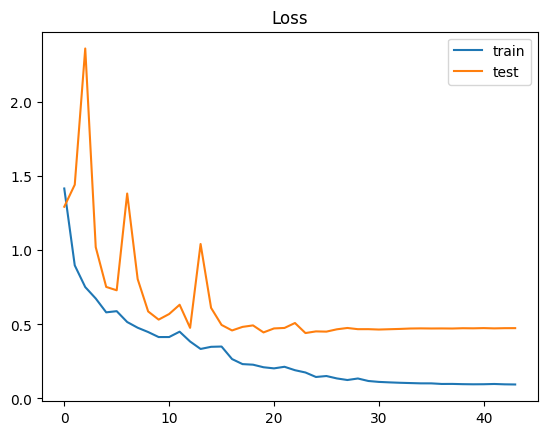

In [16]:
cnn = vgg_dropout_bn()
#cnn.summary()
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    x_train, y_train,
    epochs = 100,
    batch_size= 256,
    verbose = 1,
    validation_data=(x_val, y_val),
    callbacks=[mc,es,tob,rop]
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on validation set: {:.4f}'.format(history.history['val_accuracy'][-1]))
plot_results(all_history)

y_class = np.argmax(y_test,axis=1)
# Classify test set
pred1 = cnn(x_test).numpy()
# Classify mirrored test set
pred2 = cnn(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

In [17]:
saved_model = tf.keras.models.load_model('best_model.h5')
# Classify test set
pred1 = saved_model(x_test).numpy()
# Classify mirrored test set
pred2 = saved_model(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Results for saved best model')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

Results for saved best model
Model accuracy on test set: 0.8716
Model accuracy on mirrored test set: 0.8723
Model accuracy on combined original and mirrored test set: 0.8859


## On-the-Fly Augmentation

In [18]:
# Read data
dataset_name = 'CIFAR-10'
x_train, y_train, x_test, y_test = load_dataset(dataset_name)

val_start = int(x_train.shape[0]*0.85)
# Split training set into training and validation sets
x_train, y_train, x_val, y_val = x_train[:val_start], y_train[:val_start],x_train[val_start:], y_train[val_start:]

# Add mirrored images to validation set
x_val = np.append(x_val,x_val[:,:,::-1],axis=0)
y_val = np.append(y_val,y_val,axis=0)

In [19]:
datagen = ImageDataGenerator(
    #rotation_range=10,
    #width_shift_range=1,
    #height_shift_range=1,
    #shear_range=0.1,
    #zoom_range=0.1,
    horizontal_flip=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset: CIFAR-10
Epoch 1/100
163/167 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3296 - loss: 1.9582
Epoch 1: val_accuracy improved from None to 0.35520, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - accuracy: 0.4130 - loss: 1.6330 - val_accuracy: 0.3552 - val_loss: 2.2672 - learning_rate: 0.0100
Epoch 2/100
165/167 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5317 - loss: 1.2964
Epoch 2: val_accuracy improved from 0.35520 to 0.41147, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5175 - loss: 1.3369 - val_accuracy: 0.4115 - val_loss: 1.8098 - learning_rate: 0.0100
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5774 - loss: 1.1826
Epoch 3: val_accuracy did not improve from 0.41147
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5330 - loss: 1.3071 - val_accuracy: 0.1153 - val_loss: 8.1547 - learning_rate: 0.0100
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5071 - loss: 1.3485
Epoch 4: val_accuracy did not improve from 0.41147
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5412 - loss: 1.2664 - val_accuracy: 0.2319 - val_loss: 2.9280 - learning_rate: 0.0100
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5987 - loss: 1.1342
Epoch 5: val_accuracy did not improve from 0.41147

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 


Epoch 6: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6464 - loss: 1.0010 - val_accuracy: 0.6694 - val_loss: 0.9172 - learning_rate: 0.0050
Epoch 7/100
164/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6801 - loss: 0.8970
Epoch 7: val_accuracy improved from 0.66940 to 0.69273, saving model to best_model.h5


...


Epoch 82: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8536 - loss: 0.4095 - val_accuracy: 0.8322 - val_loss: 0.5002 - learning_rate: 1.0000e-04
Epoch 83/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8533 - loss: 0.4091
Epoch 83: val_accuracy did not improve from 0.83220
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8533 - loss: 0.4115 - val_accuracy: 0.8318 - val_loss: 0.4996 - learning_rate: 1.0000e-04
Epoch 84/100
165/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8540 - loss: 0.4106
Epoch 84: val_accuracy did not improve from 0.83220
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8530 - loss: 0.4128 - val_accuracy: 0.8277 - val_loss: 0.5070 - learning_rate: 1.0000e-04
Epoch 85/100
164/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8550 - loss: 0.4080
Epoch 85: val_accuracy did not improve from 0.83220
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8543 - loss: 0.4127 - val_accurac


Epoch 86: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8536 - loss: 0.4108 - val_accuracy: 0.8323 - val_loss: 0.5021 - learning_rate: 1.0000e-04
Epoch 87/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8497 - loss: 0.4131
Epoch 87: val_accuracy did not improve from 0.83233
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8532 - loss: 0.4081 - val_accuracy: 0.8323 - val_loss: 0.5022 - learning_rate: 1.0000e-04
Epoch 88/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8516 - loss: 0.4122
Epoch 88: val_accuracy improved from 0.83233 to 0.83267, saving model to best_model.h5



Epoch 88: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8525 - loss: 0.4132 - val_accuracy: 0.8327 - val_loss: 0.4984 - learning_rate: 1.0000e-04
Epoch 89/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8561 - loss: 0.4099
Epoch 89: val_accuracy did not improve from 0.83267
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8573 - loss: 0.4046 - val_accuracy: 0.8320 - val_loss: 0.4999 - learning_rate: 1.0000e-04
Epoch 90/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8547 - loss: 0.4104
Epoch 90: val_accuracy did not improve from 0.83267
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8552 - loss: 0.4080 - val_accuracy: 0.8315 - val_loss: 0.4999 - learning_rate: 1.0000e-04
Epoch 91/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8567 - loss: 0.4020
Epoch 91: val_accuracy did not improve from 0.83267
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8552 - loss: 0.4067 - val_accurac


Epoch 93: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8539 - loss: 0.4064 - val_accuracy: 0.8329 - val_loss: 0.5002 - learning_rate: 1.0000e-04
Epoch 94/100
164/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8549 - loss: 0.4086
Epoch 94: val_accuracy did not improve from 0.83293
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8555 - loss: 0.4047 - val_accuracy: 0.8310 - val_loss: 0.5044 - learning_rate: 1.0000e-04
Epoch 95/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8555 - loss: 0.4007
Epoch 95: val_accuracy did not improve from 0.83293
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8552 - loss: 0.4043 - val_accuracy: 0.8308 - val_loss: 0.5045 - learning_rate: 1.0000e-04
Epoch 96/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8534 - loss: 0.4070
Epoch 96: val_accuracy did not improve from 0.83293
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8538 - loss: 0.4072 - val_accurac

Results for saved best model
Model accuracy on test set: 0.8282
Model accuracy on mirrored test set: 0.8232
Model accuracy on combined original and mirrored test set: 0.8372


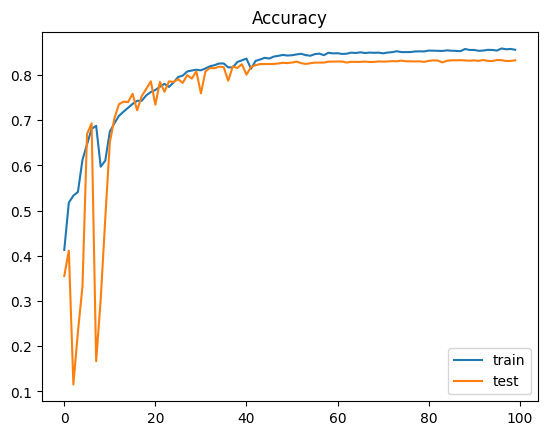

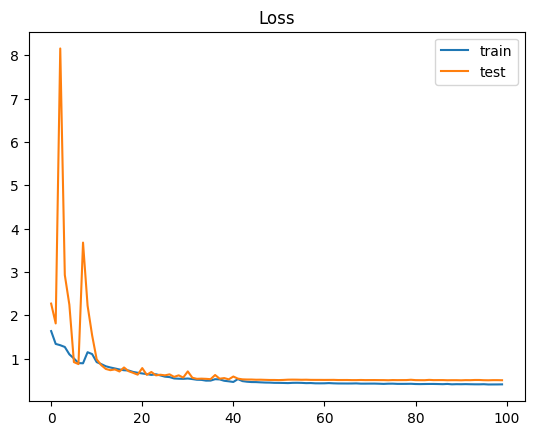

In [20]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=3, verbose=1,min_lr=0.0001)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
tob = TerminateOnBaseline(monitor='accuracy', baseline=0.99)

cnn = vgg_dropout_bn()
#cnn.summary()
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    datagen.flow(x_train, y_train, batch_size=256),
    validation_data=(x_val, y_val),
    epochs = 100,
    verbose = 1,
    callbacks=[mc,es,tob,rop]
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on validation set: {:.4f}'.format(history.history['val_accuracy'][-1]))
plot_results(all_history)

y_class = np.argmax(y_test,axis=1)
# Classify test set
pred1 = cnn(x_test).numpy()
# Classify mirrored test set
pred2 = cnn(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

saved_model = tf.keras.models.load_model('best_model.h5')
# Classify test set
pred1 = saved_model(x_test).numpy()
# Classify mirrored test set
pred2 = saved_model(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Results for saved best model')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

Network with Parallel Branches

In [21]:
def cnn_model_api(input_shape=(32,32,3)):
  inputs = Input(shape=input_shape)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(inputs)
  branch1 = Conv2D(32, kernel_size=(3, 3),activation='relu', padding='same')(branch1)
  branch2 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(1, 1),activation='relu', padding='same')(inputs)
  branch3 = Conv2D(32, kernel_size=(5, 5),activation='relu', padding='same')(branch3)
  concatanated = Concatenate()([branch1,branch2,branch3])
  net = MaxPooling2D(pool_size=(2, 2))(concatanated)
  net = BatchNormalization()(net)
  net = Dropout(0.2)(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(64, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = BatchNormalization()(net)
  net = Dropout(0.2)(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = Conv2D(128, kernel_size=(3, 3),activation='relu', padding='same')(net)
  net = MaxPooling2D(pool_size=(2, 2))(net)
  net = BatchNormalization()(net)
  net = Dropout(0.2)(net)
  net = Flatten()(net)
  net = Dense(128, activation='relu')(net)
  net = Dropout(0.2)(net)
  outputs = Dense(10, activation='softmax')(net)
  model = Model(inputs=inputs, outputs=outputs, name='classification_model')
  return model

Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │        128 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_18[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │      2,432 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │     25,632 │ conv2d_21[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_19[0][0],  │
│ (Concatenate)       │ 96)               │            │ conv2d_20[0][0],  │
│                     │                   │            │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 16, 16,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        384 │ max_pooling2d_9[… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Dropout)           │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 16, 16,    │     55,360 │ dropout_12[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 16, 16,    │     36,928 │ conv2d_23[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 8, 8, 64)  │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 64)  │        256 │ max_pooling2d_10… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 8, 8, 128) │    147,584 │ conv2d_25[0][0] 

 Total params: 616,778 (2.35 MB)

 Trainable params: 616,202 (2.35 MB)

 Non-trainable params: 576 (2.25 KB)

...


Epoch 65: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9217 - loss: 0.2178 - val_accuracy: 0.8667 - val_loss: 0.4575 - learning_rate: 5.0000e-04
Epoch 66/100
165/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9254 - loss: 0.2070
Epoch 66: val_accuracy did not improve from 0.86667
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9244 - loss: 0.2102 - val_accuracy: 0.8642 - val_loss: 0.4633 - learning_rate: 5.0000e-04
Epoch 67/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9246 - loss: 0.2104
Epoch 67: val_accuracy did not improve from 0.86667
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9237 - loss: 0.2108 - val_accuracy: 0.8663 - val_loss: 0.4600 - learning_rate: 5.0000e-04
Epoch 68/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9225 - loss: 0.2135
Epoch 68: val_accuracy did not improve from 0.86667
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9230 - loss: 0.2133 - val_accurac


Epoch 72: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9280 - loss: 0.1978 - val_accuracy: 0.8669 - val_loss: 0.4679 - learning_rate: 5.0000e-04
Epoch 73/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9305 - loss: 0.1945
Epoch 73: val_accuracy did not improve from 0.86687
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9274 - loss: 0.2011 - val_accuracy: 0.8614 - val_loss: 0.4780 - learning_rate: 5.0000e-04
Epoch 74/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9266 - loss: 0.2020
Epoch 74: val_accuracy did not improve from 0.86687
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9272 - loss: 0.1997 - val_accuracy: 0.8635 - val_loss: 0.4779 - learning_rate: 5.0000e-04
Epoch 75/100
165/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9287 - loss: 0.1985
Epoch 75: val_accuracy did not improve from 0.86687
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9292 - loss: 0.1984 - val_accurac


Epoch 77: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9327 - loss: 0.1906 - val_accuracy: 0.8684 - val_loss: 0.4689 - learning_rate: 5.0000e-04
Epoch 78/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9332 - loss: 0.1878
Epoch 78: val_accuracy did not improve from 0.86840
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9323 - loss: 0.1891 - val_accuracy: 0.8670 - val_loss: 0.4722 - learning_rate: 5.0000e-04
Epoch 79/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9321 - loss: 0.1929
Epoch 79: val_accuracy did not improve from 0.86840
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9316 - loss: 0.1925 - val_accuracy: 0.8681 - val_loss: 0.4702 - learning_rate: 5.0000e-04
Epoch 80/100
165/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9348 - loss: 0.1837
Epoch 80: val_accuracy did not improve from 0.86840
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9331 - loss: 0.1869 - val_accurac


Epoch 81: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9328 - loss: 0.1884 - val_accuracy: 0.8685 - val_loss: 0.4729 - learning_rate: 5.0000e-04
Epoch 82/100
165/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9336 - loss: 0.1823
Epoch 82: val_accuracy did not improve from 0.86847
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9320 - loss: 0.1861 - val_accuracy: 0.8676 - val_loss: 0.4761 - learning_rate: 5.0000e-04
Epoch 83/100
165/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9334 - loss: 0.1859
Epoch 83: val_accuracy did not improve from 0.86847
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9339 - loss: 0.1864 - val_accuracy: 0.8667 - val_loss: 0.4859 - learning_rate: 5.0000e-04
Epoch 84/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9343 - loss: 0.1871
Epoch 84: val_accuracy did not improve from 0.86847
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9346 - loss: 0.1841 - val_accurac

Model accuracy on test set: 0.8635
Model accuracy on mirrored test set: 0.8596
Model accuracy on combined original and mirrored test set: 0.8720
Results for saved best model
Model accuracy on test set: 0.8609
Model accuracy on mirrored test set: 0.8613
Model accuracy on combined original and mirrored test set: 0.8726


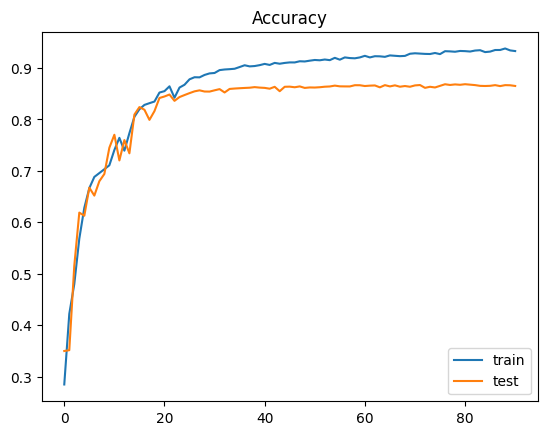

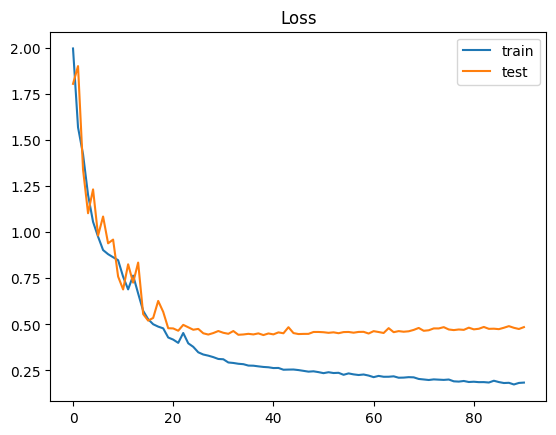

In [22]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=3, verbose=1,min_lr=0.0005)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
tob = TerminateOnBaseline(monitor='accuracy', baseline=0.99)

cnn = cnn_model_api()
cnn.summary()
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    datagen.flow(x_train, y_train, batch_size=256),
    validation_data=(x_val, y_val),
    epochs = 100,
    verbose = 1,
    callbacks=[mc,es,tob,rop]
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on validation set: {:.4f}'.format(history.history['val_accuracy'][-1]))
plot_results(all_history)

y_class = np.argmax(y_test,axis=1)
# Classify test set
pred1 = cnn(x_test).numpy()
# Classify mirrored test set
pred2 = cnn(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

saved_model = tf.keras.models.load_model('best_model.h5')
# Classify test set
pred1 = saved_model(x_test).numpy()
# Classify mirrored test set
pred2 = saved_model(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Results for saved best model')
print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

## Pretrained CNN Models

Pre-trained models can be found here:
https://keras.io/api/applications/

In [23]:
from keras.layers import *

In [24]:
from keras.applications import *

In [25]:
#pretrained_model = VGG16(weights='imagenet', include_top=False)
pretrained_model = ResNet50(weights='imagenet', include_top=False)

# We may want to make original layers not traibable
#for layer in pretrained_model.layers: layer.trainable=False

#Create your own input format (here 3x200x200)
input = Input(shape=(32,32, 3),name = 'image_input')

#Use the generated model
output_pretrained = pretrained_model(input)
x = Dropout(0.2)(output_pretrained)
x = Flatten(name='flatten')(x)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu', name='fc1')(x)
x = Dropout(0.2)(x)
#x = Dense(128, activation='relu', name='fc2')(x)
#x = Dropout(0.1)(x)
x = Dense(10, activation='softmax', name='predictions')(x)

cnn = Model(inputs=input, outputs=x, name='classification_model')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [26]:
cnn.summary()

Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 1, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 24,061,706 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

Dataset: CIFAR-10
Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.4445 - loss: 1.8414
Epoch 1: val_accuracy improved from None to 0.10140, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 109s 273ms/step - accuracy: 0.5569 - loss: 1.3626 - val_accuracy: 0.1014 - val_loss: 5.0696 - learning_rate: 0.0010
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6167 - loss: 1.1771
Epoch 2: val_accuracy did not improve from 0.10140
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.6683 - loss: 0.9994 - val_accuracy: 0.1000 - val_loss: 3.3887 - learning_rate: 0.0010
Epoch 3/100
165/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7530 - loss: 0.7452
Epoch 3: val_accuracy improved from 0.10140 to 0.16547, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.7407 - loss: 0.7782 - val_accuracy: 0.1655 - val_loss: 2.6752 - learning_rate: 0.0010
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6708 - loss: 0.9940
Epoch 4: val_accuracy did not improve from 0.16547
167/167 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6765 - loss: 0.9684 - val_accuracy: 0.1342 - val_loss: 3.9067 - learning_rate: 0.0010
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7629 - loss: 0.7085
Epoch 5: val_accuracy improved from 0.16547 to 0.46860, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.7646 - loss: 0.7008 - val_accuracy: 0.4686 - val_loss: 1.9448 - learning_rate: 0.0010
Epoch 6/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7959 - loss: 0.6090
Epoch 6: val_accuracy improved from 0.46860 to 0.70060, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.7799 - loss: 0.6552 - val_accuracy: 0.7006 - val_loss: 0.9241 - learning_rate: 0.0010
Epoch 7/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8115 - loss: 0.5624
Epoch 7: val_accuracy improved from 0.70060 to 0.74387, saving model to best_model.h5


...


Epoch 27: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9200 - loss: 0.2441 - val_accuracy: 0.7953 - val_loss: 0.7197 - learning_rate: 1.2500e-04
Epoch 28/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9329 - loss: 0.2055
Epoch 28: val_accuracy did not improve from 0.79533
167/167 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9328 - loss: 0.2033 - val_accuracy: 0.7774 - val_loss: 0.8153 - learning_rate: 1.2500e-04
Epoch 29/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9278 - loss: 0.2186
Epoch 29: val_accuracy did not improve from 0.79533

Epoch 29: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9271 - loss: 0.2197 - val_accuracy: 0.7916 - val_loss: 0.7802 - learning_rate: 1.2500e-04
Epoch 30/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9445 - loss: 0.1648
Epoch 30: val_accuracy did not improve from 0.79533
167/167 ━━━


Epoch 36: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9652 - loss: 0.1080 - val_accuracy: 0.7961 - val_loss: 0.9413 - learning_rate: 1.5625e-05
Epoch 37/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9697 - loss: 0.0971
Epoch 37: val_accuracy did not improve from 0.79613
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9682 - loss: 0.0997 - val_accuracy: 0.7953 - val_loss: 0.9716 - learning_rate: 1.5625e-05
Epoch 38/100
165/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9701 - loss: 0.0949
Epoch 38: val_accuracy did not improve from 0.79613

Epoch 38: ReduceLROnPlateau reducing learning rate to 1e-05.
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9693 - loss: 0.0953 - val_accuracy: 0.7950 - val_loss: 0.9631 - learning_rate: 1.5625e-05
Epoch 39/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9698 - loss: 0.0963
Epoch 39: val_accuracy did not improve from 0.79613
167/167 ━━━━━━━━━━━━━━━━━━━


Epoch 41: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9738 - loss: 0.0843 - val_accuracy: 0.7963 - val_loss: 0.9985 - learning_rate: 1.0000e-05
Epoch 42/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9748 - loss: 0.0794
Epoch 42: val_accuracy improved from 0.79633 to 0.79640, saving model to best_model.h5



Epoch 42: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9735 - loss: 0.0834 - val_accuracy: 0.7964 - val_loss: 1.0122 - learning_rate: 1.0000e-05
Epoch 43/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9737 - loss: 0.0845
Epoch 43: val_accuracy did not improve from 0.79640
167/167 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.9740 - loss: 0.0839 - val_accuracy: 0.7949 - val_loss: 1.0218 - learning_rate: 1.0000e-05
Epoch 44/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9759 - loss: 0.0786
Epoch 44: val_accuracy did not improve from 0.79640
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9750 - loss: 0.0811 - val_accuracy: 0.7950 - val_loss: 1.0356 - learning_rate: 1.0000e-05
Epoch 45/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9759 - loss: 0.0774
Epoch 45: val_accuracy did not improve from 0.79640
167/167 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9753 - loss: 0.0791 - val_accura


Epoch 49: finished saving model to best_model.h5
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9765 - loss: 0.0744 - val_accuracy: 0.7965 - val_loss: 1.0695 - learning_rate: 1.0000e-05
Epoch 50/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9766 - loss: 0.0750
Epoch 50: val_accuracy did not improve from 0.79647
167/167 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9779 - loss: 0.0692 - val_accuracy: 0.7952 - val_loss: 1.0848 - learning_rate: 1.0000e-05
Epoch 51/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9766 - loss: 0.0709
Epoch 51: val_accuracy did not improve from 0.79647
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9771 - loss: 0.0706 - val_accuracy: 0.7946 - val_loss: 1.0967 - learning_rate: 1.0000e-05
Epoch 52/100
166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9789 - loss: 0.0685
Epoch 52: val_accuracy did not improve from 0.79647
167/167 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9780 - loss: 0.0711 - val_accura

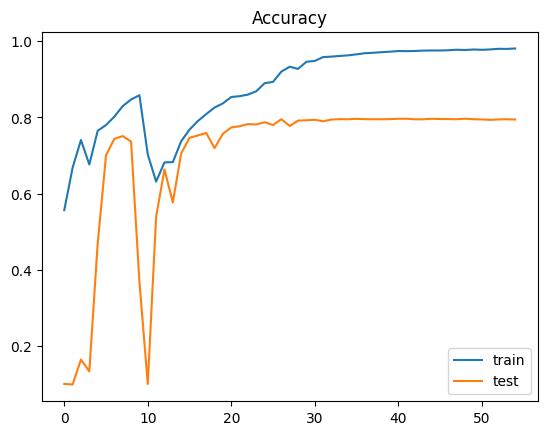

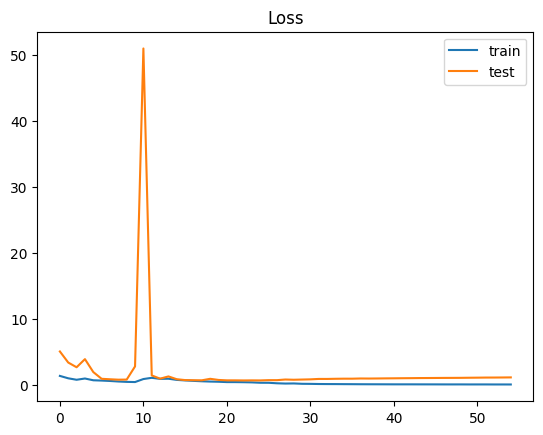

In [27]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=3, verbose=1,min_lr=0.00001)
mc = ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=10)
tob = TerminateOnBaseline(monitor='accuracy', baseline=0.98)

#cnn.summary()
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

print('Dataset:',dataset_name)

history = cnn.fit(
    datagen.flow(x_train, y_train, batch_size=256),
    validation_data=(x_val, y_val),
    epochs = 100,
    verbose = 1,
    callbacks=[mc,es,tob,rop]
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on validation set: {:.4f}'.format(history.history['val_accuracy'][-1]))
plot_results(all_history)

y_class = np.argmax(y_test,axis=1)
# Classify test set
pred1 = cnn(x_test).numpy()
# Classify mirrored test set
pred2 = cnn(x_test[:,:,::-1]).numpy()
pred = np.argmax(pred1+pred2,axis=1)

print('Model accuracy on test set: {:.4f}'.format(accuracy_score(np.argmax(pred1,axis=1),y_class)))
print('Model accuracy on mirrored test set: {:.4f}'.format(accuracy_score(np.argmax(pred2,axis=1),y_class)))
print('Model accuracy on combined original and mirrored test set: {:.4f}'.format(accuracy_score(pred,y_class)))

Predicting using 9 augmentations.

In [28]:
x_test_aug = np.zeros((x_test.shape[0],34,34,3),dtype=np.float32)
x_test_aug[:,1:-1,1:-1] = x_test
x_test_aug[:,1:-1,0] = x_test_aug[:,1:-1,1]
x_test_aug[:,1:-1,-1] = x_test_aug[:,1:-1,-2]
x_test_aug[:,0] = x_test_aug[:,1]
x_test_aug[:,-1] = x_test_aug[:,-2]

In [29]:
pred = 0
for i in range(1,2):
  for j in range(1,2):
    pred += cnn(x_test_aug[:,i:i+32,j:j+32]).numpy()

In [30]:
pred_vote = np.argmax(pred,axis=1)

print('Model accuracy on augmented test set: {:.4f}'.format(accuracy_score(pred_vote,y_class)))

Model accuracy on augmented test set: 0.7980
